# Оценка RAG-пайплайна и анализ результатов

## Предварительные требования

1. Qdrant запущен, документы проиндексированы (см. `01_baseline.ipynb`)
2. Ollama запущена с моделями для генерации и LLM-as-judge
3. Датасет сгенерирован:
   ```
   cd research/rag_experiments
   python -m scripts.generate_eval_dataset --testset_size 200 --seed 42
   ```

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd().parent))

from src.config import get_cfg, BASE_DIR
from src.eval import run_full_evaluation

cfg = get_cfg()
RESULTS_DIR = Path.cwd().parent / "results"
RESULTS_DIR.mkdir(exist_ok=True)
print("Results dir:", RESULTS_DIR.relative_to(BASE_DIR))

Results dir: research/rag_experiments/results


## Запуск оценки

Полная оценка: ретривер (Recall@K, Precision@K, MAP@K, NDCG@K, Hit Rate) + пайплайн (chrF++, ROUGE, semantic similarity, LLM-as-judge).

In [2]:
results = run_full_evaluation(
    cfg,
    dataset_hf_filename="boardgame_rules_qa_dataset_ru_chunk512.jsonl",
    output_path=RESULTS_DIR / "baseline_full_eval.json",
)
print("Модели:", results.get("models", {}))
print("Оценено сэмплов:", results.get("n_evaluated", 0), "/", results.get("n_samples", 0))
pipe = results.get("pipeline", {})
if pipe.get("llm_n_scored_faithfulness") is not None:
    n = int(pipe["llm_n_scored_faithfulness"])
    na_f = int(pipe.get("llm_n_na_faithfulness", 0))
    na_r = int(pipe.get("llm_n_na_relevance", 0))
    na_c = int(pipe.get("llm_n_na_correctness", 0))
    print(
        "LLM-judge: scored on", n, "samples"
        + (f", N/A (faith/rel/corr): {na_f}/{na_r}/{na_c}" if (na_f or na_r or na_c) else "")
    )

Using device: mps


Pipeline eval:   0%|          | 0/200 [00:00<?, ?samp/s]Some weights of RobertaModel were not initialized from the model checkpoint at ai-forever/ru-en-RoSBERTa and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
LLM-as-judge: 100%|██████████| 200/200 [03:40<00:00,  1.10s/samp]

Модели: {'generation': 'qwen2.5:1.5b', 'embedding': 'intfloat/multilingual-e5-base', 'semantic_eval': 'ai-forever/ru-en-RoSBERTa', 'llm_judge': 'qwen2.5:7b-instruct'}
Оценено сэмплов: 200 / 200
LLM-judge: scored on 200 samples


## Метрики

In [3]:
PIPELINE_SERVICE_KEYS = {
    "n_evaluated", "errors", "llm_judge_errors",
    "llm_n_scored_faithfulness", "llm_n_scored_relevance", "llm_n_scored_correctness",
    "llm_n_na_faithfulness", "llm_n_na_relevance", "llm_n_na_correctness",
    "llm_faithfulness_scores", "llm_relevance_scores", "llm_correctness_scores",
}

metrics_flat = []
for name, val in results.get("retriever", {}).items():
    metrics_flat.append({"блок": "retriever", "метрика": name, "значение": val})
for name, val in results.get("pipeline", {}).items():
    if name not in PIPELINE_SERVICE_KEYS:
        metrics_flat.append({"блок": "pipeline", "метрика": name, "значение": val})

metrics_df = pd.DataFrame(metrics_flat)

In [4]:
print("Ретривер:")
display(pd.DataFrame(list(results["retriever"].items()), columns=["метрика", "значение"]))
print("Пайплайн:")
pipe_items = [(k, v) for k, v in results["pipeline"].items() if k not in PIPELINE_SERVICE_KEYS]
display(pd.DataFrame(pipe_items, columns=["метрика", "значение"]))

Ретривер:


,метрика,значение
0,recall_at_k,0.693333
1,precision_at_k,0.182000
2,map_at_k,0.533222
3,ndcg_at_k,0.585582
4,hit_rate,0.750000


Пайплайн:


,метрика,значение
0,chrfpp,0.344467
1,rouge1_recall,0.612631
2,rouge2_recall,0.397663
3,rougeL_f1,0.262656
4,semantic_similarity,0.699523
5,llm_faithfulness,0.756250
6,llm_answer_relevance,0.666250
7,llm_correctness,0.654523


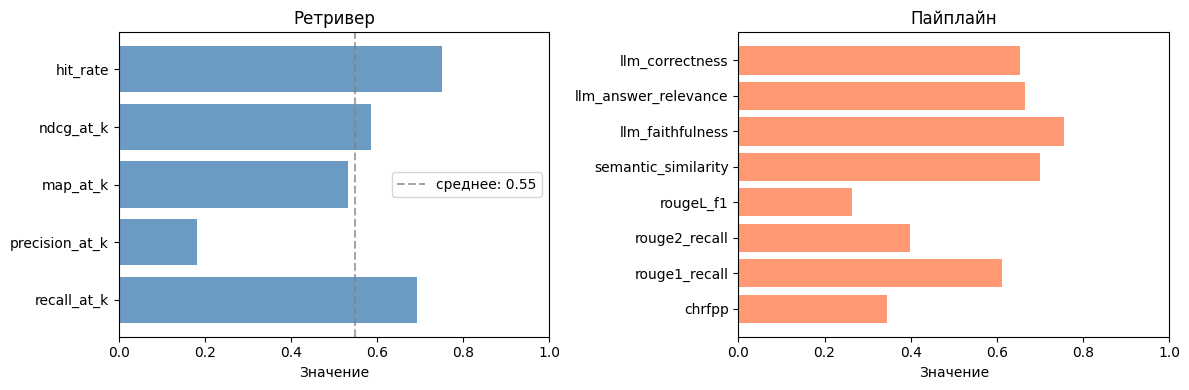

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ret = metrics_df[metrics_df["блок"] == "retriever"]
ax = axes[0]
bars = ax.barh(ret["метрика"], ret["значение"], color="steelblue", alpha=0.8)
ax.set_xlim(0, 1)
ax.set_xlabel("Значение")
ax.set_title("Ретривер")
ax.axvline(x=ret["значение"].mean(), color="gray", linestyle="--", alpha=0.7, label=f"среднее: {ret['значение'].mean():.2f}")
ax.legend()

pipe = metrics_df[metrics_df["блок"] == "pipeline"]
ax = axes[1]
bars = ax.barh(pipe["метрика"], pipe["значение"], color="coral", alpha=0.8)
ax.set_xlim(0, 1)
ax.set_xlabel("Значение")
ax.set_title("Пайплайн")
plt.tight_layout()
plt.show()

### Распределение оценок LLM-судьи по сэмплам

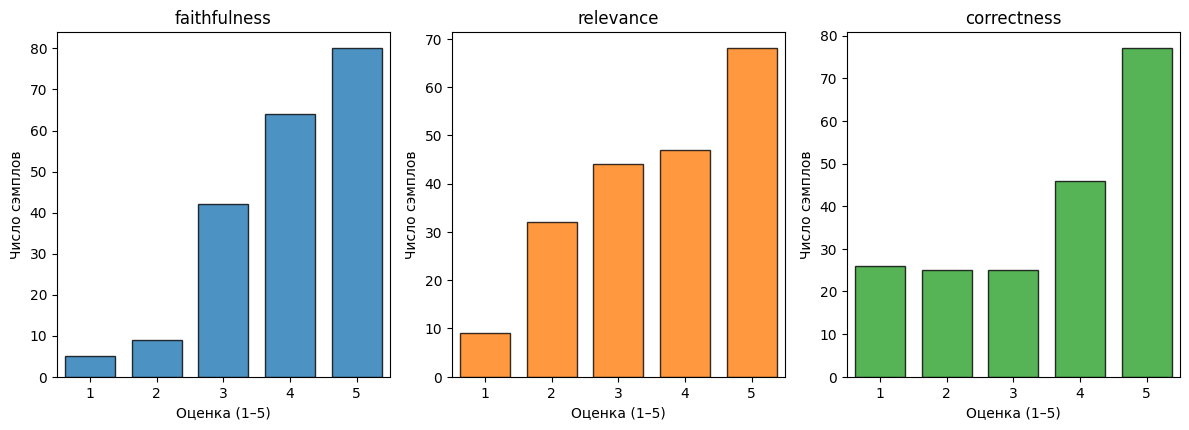

In [6]:
pipe = results.get("pipeline", {})
f_scores = pipe.get("llm_faithfulness_scores") or []
r_scores = pipe.get("llm_relevance_scores") or []
c_scores = pipe.get("llm_correctness_scores") or []

f_vals = np.array([x for x in f_scores if x is not None], dtype=float) if f_scores else np.array([])
r_vals = np.array([x for x in r_scores if x is not None], dtype=float) if r_scores else np.array([])
c_vals = np.array([x for x in c_scores if x is not None], dtype=float) if c_scores else np.array([])

fig = plt.figure(figsize=(12, 8))
for idx, (vals, title) in enumerate([
    (f_vals, "faithfulness"),
    (r_vals, "relevance"),
    (c_vals, "correctness"),
]):
    ax = fig.add_subplot(2, 3, idx + 1)
    if len(vals):
        ax.hist(
            vals,
            bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
            range=(0.5, 5.5),
            color=f"C{idx}",
            edgecolor="black",
            alpha=0.8,
            rwidth=0.75
        )
    ax.set_xlabel("Оценка (1–5)")
    ax.set_ylabel("Число сэмплов")
    ax.set_title(title)
    ax.set_xlim(0.5, 5.5)

plt.tight_layout()
plt.show()

По гистограммам видно, как оценки LLM-судьи распределены по сэмплам: смещение к высоким (4-5) может говорить как о стабильном качестве ответов по соответствующему критерию, так и о довольно простом наборе вопросов в валидационном датасете.

### Интерпретация метрик

In [7]:
retrieval = results["retriever"]
pipe = results["pipeline"]

print(f"Ретривер: Recall@K={retrieval.get('recall_at_k', 0):.2%} - доля gold-чанков в top-K")
print(f"Ретривер: Precision@K={retrieval.get('precision_at_k', 0):.2%} - доля релевантных среди выданных в top-K")
print(f"Ретривер: MAP@K={retrieval.get('map_at_k', 0):.3f} - средняя точность по позициям релевантных в top-K")
print(f"Ретривер: NDCG@K={retrieval.get('ndcg_at_k', 0):.3f} - качество ранжирования с учётом порядка")
print(f"Ретривер: Hit Rate={retrieval.get('hit_rate', 0):.2%} - доля вопросов, где хотя бы 1 gold найден")
print(f"Пайплайн: chrF++={pipe.get('chrfpp', 0):.3f}, ROUGE-L={pipe.get('rougeL_f1', 0):.3f} - совпадение с эталоном")
print(f"Пайплайн: semantic_similarity={pipe.get('semantic_similarity', 0):.3f} - смысловая близость")
if "llm_faithfulness" in pipe:
    print(f"LLM-judge: faithfulness={pipe['llm_faithfulness']:.2f}, relevance={pipe['llm_answer_relevance']:.2f}, correctness={pipe['llm_correctness']:.2f}")

Ретривер: Recall@K=69.33% - доля gold-чанков в top-K
Ретривер: Precision@K=18.20% - доля релевантных среди выданных в top-K
Ретривер: MAP@K=0.533 - средняя точность по позициям релевантных в top-K
Ретривер: NDCG@K=0.586 - качество ранжирования с учётом порядка
Ретривер: Hit Rate=75.00% - доля вопросов, где хотя бы 1 gold найден
Пайплайн: chrF++=0.344, ROUGE-L=0.263 - совпадение с эталоном
Пайплайн: semantic_similarity=0.700 - смысловая близость
LLM-judge: faithfulness=0.76, relevance=0.67, correctness=0.65


## Выводы по результатам оценки бейзлайна

### Ретривер
- **Recall@K / Hit Rate** - нужный документ/факт часто попадает в топ‑k.
- **Precision@K** - внутри топ‑k много шума: релевантных фрагментов мало относительно общего объёма контекста.
- **MAP@K** - релевантные чанки часто попадают в top-K, но не всегда в начале списка.
- **NDCG@K** - ранжирование так себе: релевантное есть, но не всегда наверху, поэтому LLM может не увидеть/не выбрать нужный кусок.

**Итог:** Ретривер в целом находит релевантный контекст для большинства вопросов, но нужно идти в сторону улучшения precision/ranking.

### Пайплайн
- **chrF++ / ROUGE** - умеренные значения типичны для свободной генерации: модель часто передаёт тот же смысл другими словами.
- **Semantic similarity** - по смыслу ответы часто совпадают с эталоном, даже при иной формулировке.
- **LLM-as-judge (faithfulness, relevance, correctness)** - faithfulness 0.76 - ответ в основном опирается на контекст; relevance 0.67 - ответы чаще релевантные; correctness 0.65 - факты часто совпадают с эталоном.

**Итог:** Бейзлайн даёт приемлемое качество по смыслу, но ретривер слегка "душит", из-за чего качество ответов падает

### Варианты улучшения
- **Реранкер:** передавать генератору не сырой top‑k, а результат переранжирования cross‑encoder’ом (или гибрид dense+BM25 с последующим rerank). Также подобрать k.
- **Метаданные:** фильтровать по полю game_title, если вопрос явно про конкретную игру.
- **Режим «не знаю»:** если в контексте нет ответа - кратко сказать, чего не хватает.
- **Формат ответа:** просить модель отвечать коротко, по пунктам и копировать ключевые формулировки из контекста.